# Advanced Data Mining for Data-Driven Insights and Predictive Modeling

## Deliverable 1: Data Collection, Cleaning, and Exploration

Student Name: Bishnu Sharma         
Course: MSCS 634  
Date: 11 March 2026

## Project Overview

This project focuses on applying data mining techniques to analyze a real-world dataset and extract meaningful insights. The dataset used in this analysis is the Bank Marketing Dataset obtained from the UCI Machine Learning Repository. It contains information about direct marketing campaigns conducted by a Portuguese banking institution.

The objective of this analysis is to explore customer demographic and financial attributes to better understand patterns that influence whether a customer subscribes to a term deposit.

The analysis process includes several stages:
- Data collection and loading
- Data cleaning and preprocessing
- Exploratory data analysis (EDA)
- Visualization of key patterns and relationships

The insights derived from this analysis will help guide further predictive modeling and data mining tasks in later stages of the project.

## Dataset Description

The dataset used in this project is the Bank Marketing Dataset obtained from the UCI Machine Learning Repository. It contains information about direct marketing campaigns conducted by a Portuguese banking institution. The goal of the campaign was to determine whether a client would subscribe to a term deposit.

The dataset includes 45,211 records and 17 attributes that describe customer demographic information, financial status, and previous marketing interactions.

Key attributes include:
- Age of the customer
- Job type
- Marital status
- Education level
- Account balance
- Housing loan status
- Previous marketing campaign contacts
- Outcome of previous campaigns

The target variable is **y**, which indicates whether the customer subscribed to a term deposit.

## Data Collection and Initial Exploration

In this section, the dataset is loaded into a Pandas DataFrame and inspected to understand its structure. Basic functions such as `head()`, `shape`, `info()`, and `describe()` are used to examine the dataset and gain an overview of its attributes and data types.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.shape

(45211, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Data Cleaning
In this section, we check for missing values, duplicates, and noisy data to ensure the dataset is clean and ready for analysis.

### Checking Missing Values

In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [10]:
df['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

### Handling Missing and Noisy Data

Some categorical variables contained the value "unknown", which represents missing or incomplete information. These values were replaced with missing values and filled using the most frequent value (mode).

In [11]:
df.replace("unknown", np.nan, inplace=True)

In [12]:
df.isnull().sum()

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

In [13]:
for column in df.columns:
    df[column] = df[column].fillna(df[column].mode()[0])

### Verifying Data Cleaning

In [14]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

## Data Cleaning Process

Several steps were performed to prepare the dataset for analysis.

1. The dataset was inspected using functions such as `df.head()`, `df.info()`, and `df.describe()` to understand the structure of the data.

2. The dataset was checked for missing values and duplicate records. No duplicate records were found.

3. Some categorical variables contained the value **"unknown"**, which represents missing or unclear information.

4. These values were replaced with missing values and then filled using the most frequent value (mode) for each column.

These cleaning steps ensured that the dataset was complete and ready for further analysis.

## Exploratory Data Analysis

Exploratory data analysis is performed to understand data distributions and relationships between variables using visualizations.

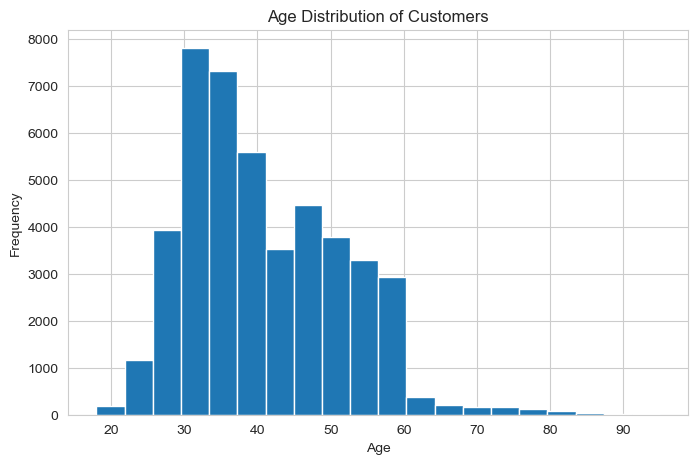

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=20)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Insight

The histogram shows the distribution of customer ages. Most customers fall between the ages of approximately 30 and 50, indicating that middle-aged individuals represent a large portion of the bank's customer base.

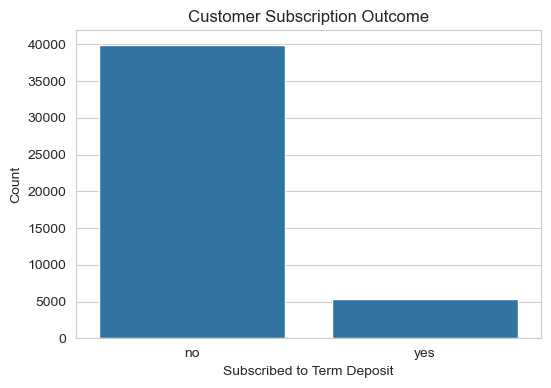

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='y', data=df)

plt.title("Customer Subscription Outcome")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Count")

plt.show()

### Insight

The bar chart shows the number of customers who subscribed to the term deposit compared to those who did not. The dataset contains significantly more customers who did not subscribe, indicating a class imbalance that may affect predictive modeling in later stages.

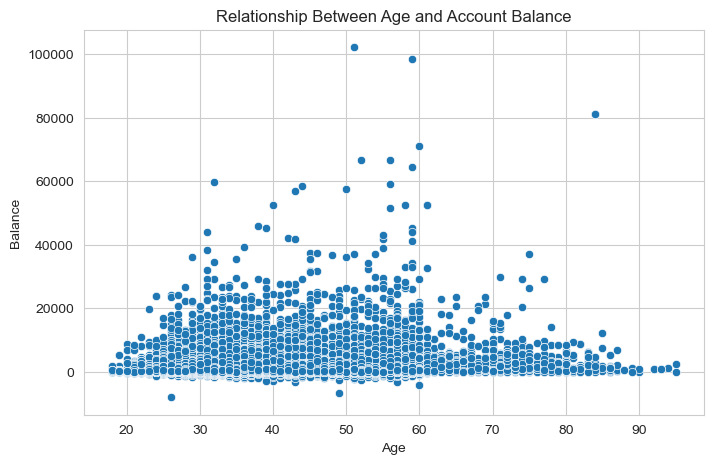

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='age', y='balance', data=df)

plt.title("Relationship Between Age and Account Balance")
plt.xlabel("Age")
plt.ylabel("Balance")

plt.show()

### Insight

The scatter plot shows the relationship between customer age and account balance. While balances vary widely across all age groups, there does not appear to be a strong linear relationship between age and account balance.

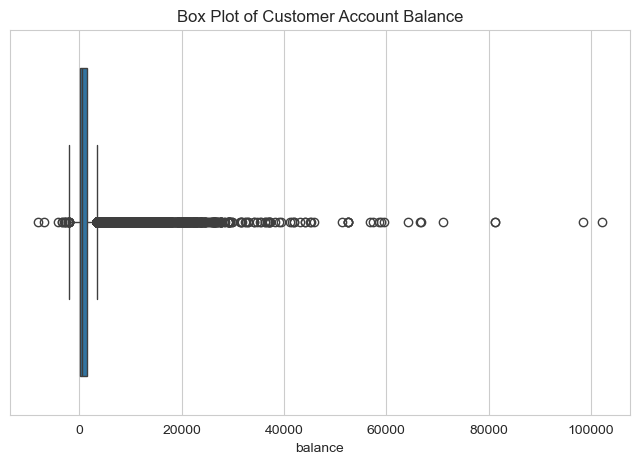

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['balance'])

plt.title("Box Plot of Customer Account Balance")

plt.show()

### Insight

The box plot reveals the distribution of customer account balances and highlights the presence of outliers. Some customers have significantly higher balances compared to the majority of the dataset.

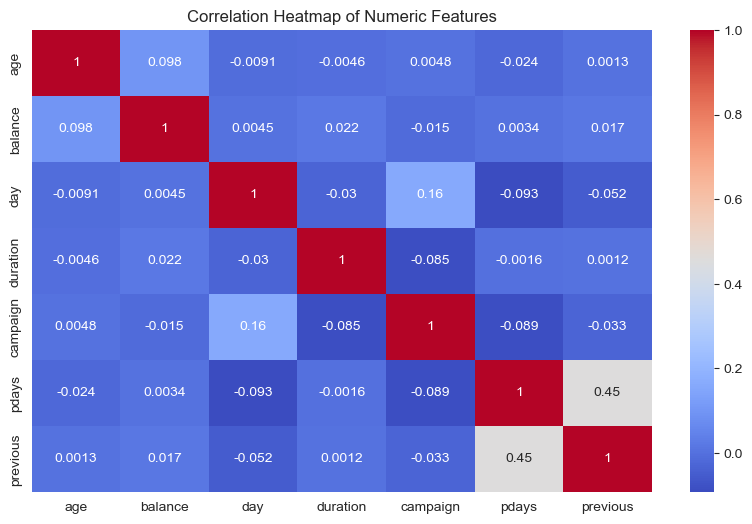

In [19]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap of Numeric Features")

plt.show()

### Insight

The correlation heatmap shows the relationships between numeric variables such as age, balance, duration, and campaign contacts. Most correlations are relatively weak, suggesting that these variables independently influence customer behavior.

### Pairplot Visualization

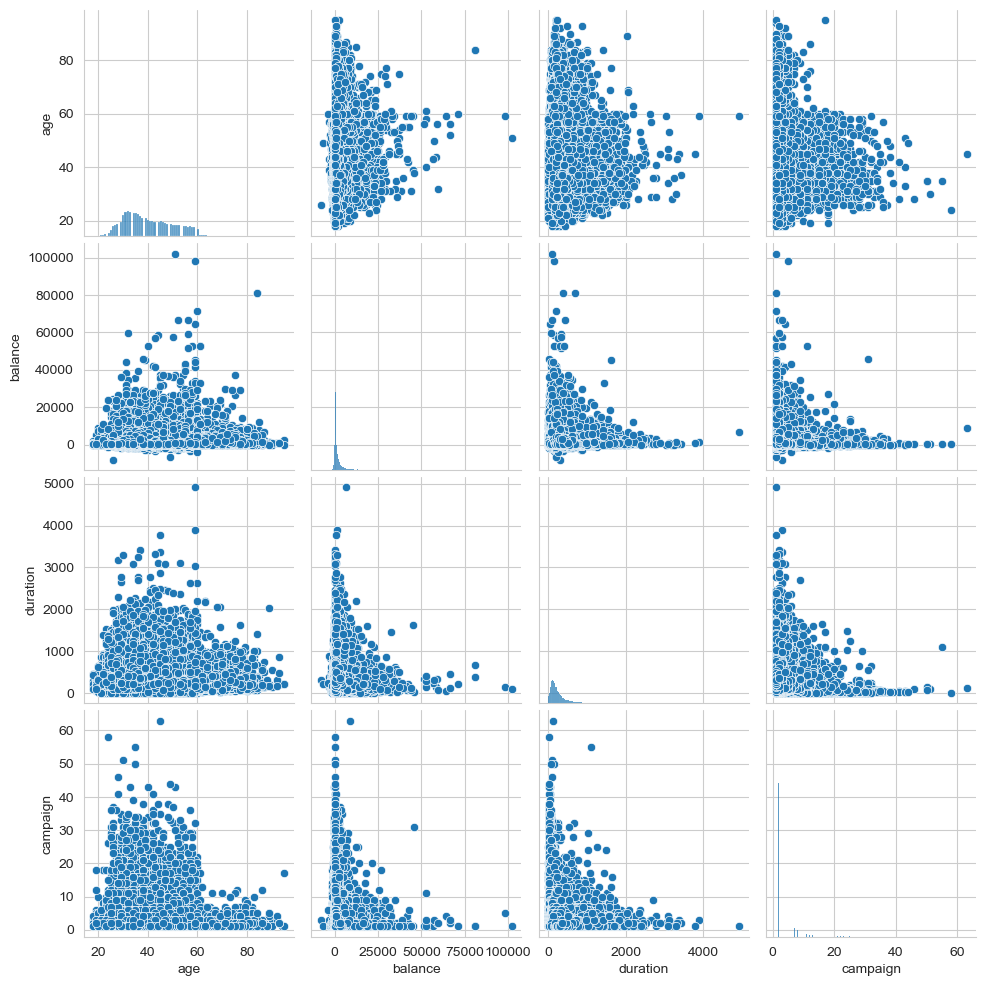

In [20]:
sns.pairplot(df[['age','balance','duration','campaign']])
plt.show()

### Insight from Pairplot

The pairplot visualization helps examine relationships between multiple numeric variables simultaneously. It shows how features such as age, balance, duration, and campaign interactions relate to each other. Most relationships appear weak or scattered, suggesting that these variables independently influence customer behavior rather than showing strong linear correlations.

## Key Insights from Exploratory Data Analysis

Several important observations were discovered during exploratory data analysis.

- The age distribution shows that most customers are between 30 and 50 years old.
- The subscription outcome visualization indicates that significantly more customers did not subscribe to the term deposit than those who did.
- The scatter plot between age and account balance shows no strong relationship between these two variables.
- The box plot revealed that some customers have very high account balances, indicating the presence of outliers.
- The correlation heatmap shows that most numeric variables have weak correlations, meaning they may independently influence customer behavior.

These insights will guide feature selection and modeling strategies in the next stages of the project.

## Challenges Encountered

One challenge encountered during the analysis was handling the "unknown" values in several categorical variables. These values represented missing or incomplete data, which required careful handling to avoid losing valuable records.

Another challenge was interpreting relationships between variables, as many numeric variables showed weak correlations. This indicates that predicting customer subscription behavior may require more advanced modeling techniques in later stages of the project.